Shape after cleaning: (4998, 22)
Date range: 1908 - 2023

Missing values (key columns):
Aboard           18
Fatalities        8
Survival_Rate    23
dtype: int64

  Total crashes recorded     : 4,998
  Total fatalities           : 111,644
  Total people aboard        : 155,356
  Overall survival rate      : 28.2%

Crashes and mean fatalities by decade:
 Decade  Crashes  Mean_Fatalities  Survival_Rate
   1900        2         1.000000       0.250000
   1910       31        13.677419       0.032708
   1920      181         3.574586       0.119869
   1930      354         5.742938       0.168412
   1940      575        15.445217       0.153404
   1950      648        18.177469       0.173275
   1960      636        26.547170       0.172948
   1970      612        32.272876       0.201392
   1980      552        30.519928       0.199029
   1990      631        25.331220       0.217563
   2000      506        22.083004       0.193734
   2010      235        27.263830       0.163262
   2020  

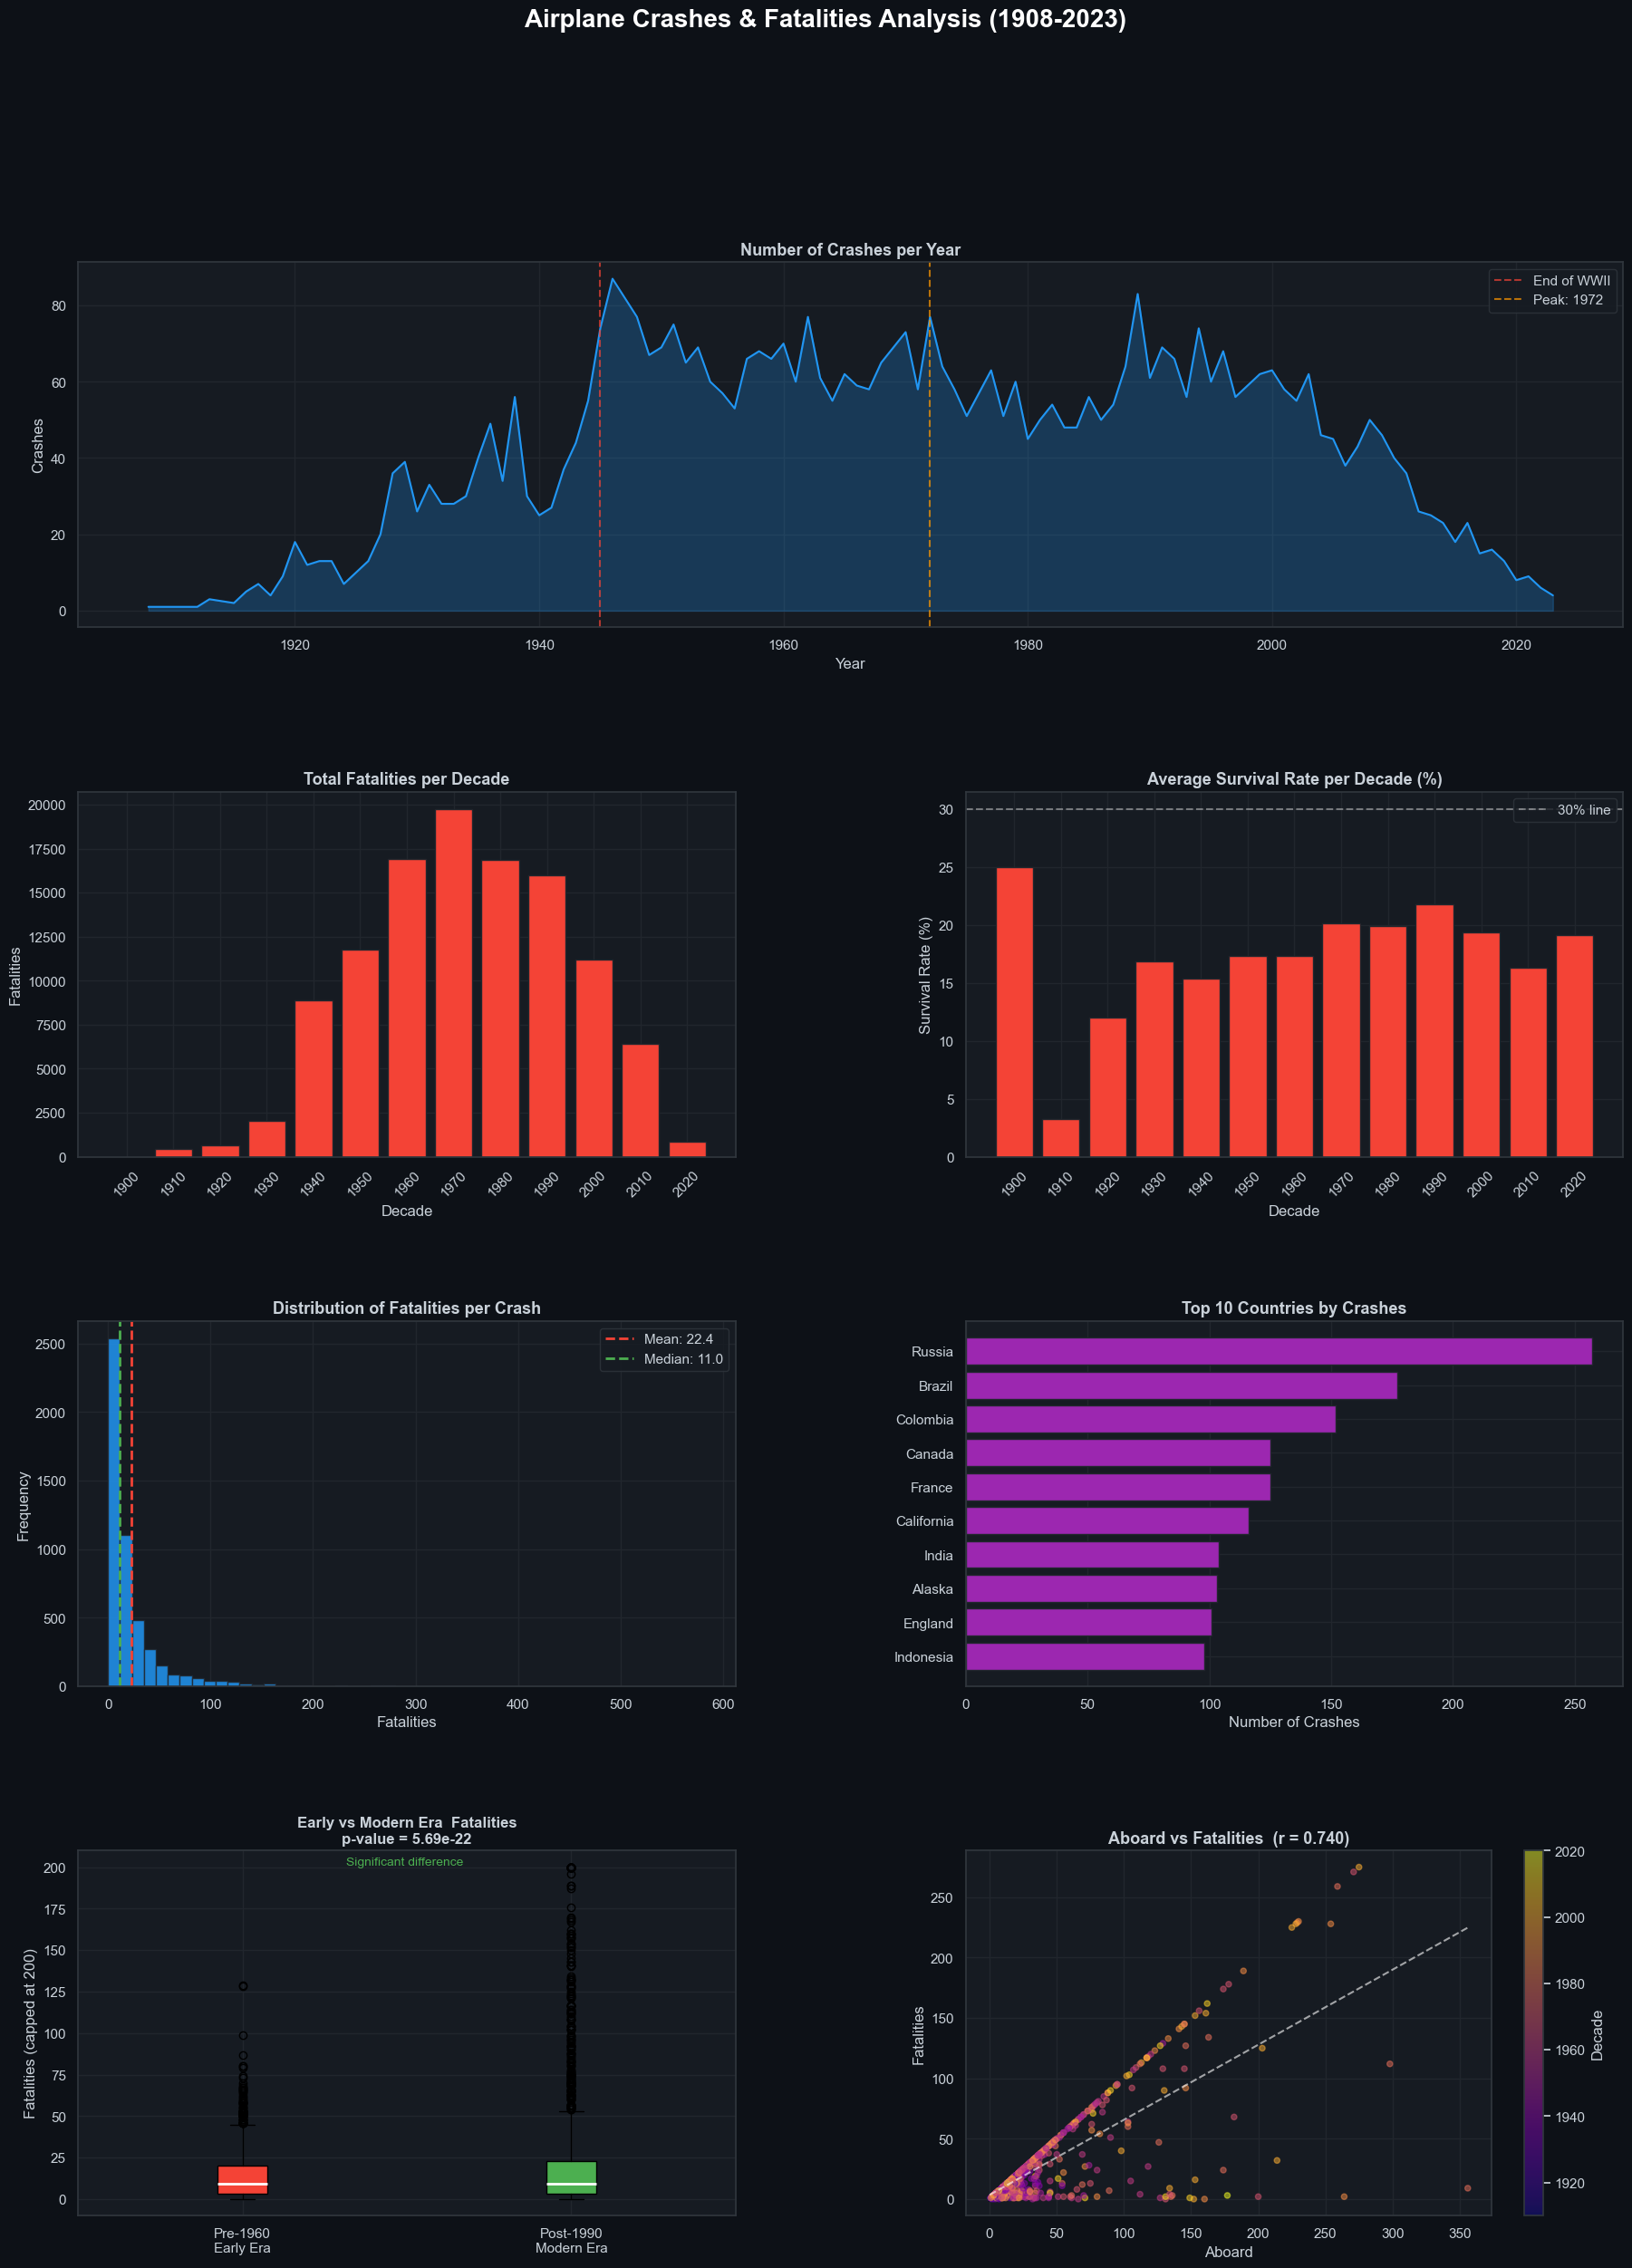

Figure saved as airplane_crashes_analysis.png

 KEY INSIGHTS & FINDINGS

 1. Scale of the problem
    - 4,998 crashes recorded from 1908 to 2023
    - 111,644 total fatalities
    - Overall survival rate: 28.2%

 2. Trend over time
    - Crashes peaked around the early 1970s, then declined after 1980.
    - WWII-era records show a spike linked to military activity.

 3. Fatality distribution
    - The distribution is right-skewed: most crashes have fewer fatalities, while rare catastrophic events raise the mean.
    - Mean fatalities (22.4) are higher than the median (11.0).

 4. Hypothesis test
    - Modern-era crashes have a higher mean fatality count than pre-1960 crashes.
    - Welch's t-test p-value: 5.69e-22, so the difference is statistically significant.

 5. Geography
    - USA has the highest crash count in this dataset.
    - Russia and Brazil also appear among the leading countries by crash count.

 6. Correlation
    - Aboard and Fatalities have a strong positive correlati

In [2]:
# ============================================================
#  AIRPLANE CRASHES & FATALITIES ANALYSIS (1908-2023)
#  Daily Challenge  Full Report
#  Tools: Pandas, NumPy, SciPy, Matplotlib, Seaborn
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ttest_ind, normaltest, describe
import warnings
from pathlib import Path
import zipfile
warnings.filterwarnings('ignore')

# 
# TASK 1 - DATA IMPORT & CLEANING
# 

# Load with latin1 to handle special characters in location names
csv_name = 'Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv'
zip_name = 'Airplane Crashes and Fatalities upto 2023.zip'
search_dirs = [Path.cwd(), Path.cwd() / 'week2' / 'Day3']
zip_path = next((folder / zip_name for folder in search_dirs if (folder / zip_name).exists()), None)

if zip_path is not None:
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(csv_name) as csv_file:
            df = pd.read_csv(csv_file, encoding='latin1')
elif Path(csv_name).exists():
    df = pd.read_csv(csv_name, encoding='latin1')
else:
    raise FileNotFoundError(f'Could not find {csv_name} or {zip_name}.')

# 1a. Parse dates
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])               # remove rows with unparseable dates
df['Year']   = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# 1b. Convert numeric columns, coerce bad strings to NaN
num_cols = ['Aboard', 'Aboard Passangers', 'Aboard Crew',
            'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Ground'] = df['Ground'].fillna(0)         # missing ground fatalities  0

# 1c. Derived columns
df['Survivors']     = df['Aboard'] - df['Fatalities']
df['Survival_Rate'] = (df['Survivors'] / df['Aboard']).clip(0, 1)
df['Country']       = df['Location'].astype(str).str.split(',').str[-1].str.strip()

print("Shape after cleaning:", df.shape)
print("Date range:", df['Year'].min(), "-", df['Year'].max())
print("\nMissing values (key columns):")
print(df[['Aboard','Fatalities','Survival_Rate']].isnull().sum())


# 
# TASK 2 - EXPLORATORY DATA ANALYSIS
# 

total_crashes    = len(df)
total_fatalities = df['Fatalities'].sum()
total_aboard     = df['Aboard'].sum()
overall_survival = (df['Survivors'].sum() / total_aboard) * 100

print("\n" + "="*55)
print(f"  Total crashes recorded     : {total_crashes:,}")
print(f"  Total fatalities           : {total_fatalities:,.0f}")
print(f"  Total people aboard        : {total_aboard:,.0f}")
print(f"  Overall survival rate      : {overall_survival:.1f}%")
print("="*55)

# Yearly aggregates
yearly = df.groupby('Year').agg(
    Crashes    = ('Fatalities', 'count'),
    Fatalities = ('Fatalities', 'sum'),
    Survival   = ('Survival_Rate', 'mean')
).reset_index()

# Decade aggregates
decade_stats = df.groupby('Decade').agg(
    Crashes          = ('Fatalities', 'count'),
    Mean_Fatalities  = ('Fatalities', 'mean'),
    Total_Fatalities = ('Fatalities', 'sum'),
    Survival_Rate    = ('Survival_Rate', 'mean')
).reset_index()

print("\nCrashes and mean fatalities by decade:")
print(decade_stats[['Decade','Crashes','Mean_Fatalities','Survival_Rate']].to_string(index=False))


# 
# TASK 3 - STATISTICAL ANALYSIS
# 

fat = df['Fatalities'].dropna()

# 3a. Descriptive statistics via SciPy
stat_desc = describe(fat)
print("\n--- Descriptive Statistics (SciPy) ---")
print(f"  n          : {stat_desc.nobs:,}")
print(f"  Mean       : {stat_desc.mean:.2f}")
print(f"  Variance   : {stat_desc.variance:.2f}")
print(f"  Std Dev    : {np.sqrt(stat_desc.variance):.2f}")
print(f"  Median     : {np.median(fat):.2f}")
print(f"  Skewness   : {stat_desc.skewness:.4f}  (positive = right-skewed)")
print(f"  Kurtosis   : {stat_desc.kurtosis:.4f}")
print(f"  Min / Max  : {stat_desc.minmax[0]:.0f} / {stat_desc.minmax[1]:.0f}")

# 3b. Hypothesis test  Early era (pre-1960) vs Modern era (post-1990)
#     H: Both eras have the same mean fatalities per crash
#     H: The eras have significantly different mean fatalities
early  = df[df['Year'] <  1960]['Fatalities'].dropna()
modern = df[df['Year'] >= 1990]['Fatalities'].dropna()

t_stat, p_val = ttest_ind(early, modern, equal_var=False)   # Welch's t-test

print("\n--- Hypothesis Test: Welch's T-Test ---")
print(f"  Early era  (pre-1960) : mean = {early.mean():.2f}, n = {len(early)}")
print(f"  Modern era (post-1990): mean = {modern.mean():.2f}, n = {len(modern)}")
print(f"  T-statistic : {t_stat:.4f}")
print(f"  P-value     : {p_val:.2e}")
print(f"  Conclusion  : {'Reject H0 - significant difference' if p_val < 0.05 else 'Fail to reject H0'}")

# 3c. Pearson correlation  Aboard vs Fatalities
corr_data = df[['Aboard','Fatalities']].dropna()
r, p_corr = __import__('scipy').stats.pearsonr(corr_data['Aboard'], corr_data['Fatalities'])
print(f"\n--- Pearson Correlation: Aboard vs Fatalities ---")
print(f"  r = {r:.4f}  (p = {p_corr:.2e})")


# 
# TASK 4 - VISUALIZATION  (7 charts in one figure)
# 

sns.set_theme(style="darkgrid")
PALETTE = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":"#c9d1d9",
    "xtick.color":"#c9d1d9","ytick.color":"#c9d1d9",
    "text.color":"#c9d1d9","grid.color":"#21262d",
    "legend.facecolor":"#161b22","legend.edgecolor":"#30363d",
})

fig = plt.figure(figsize=(22, 28), facecolor="#0d1117")
fig.suptitle("Airplane Crashes & Fatalities Analysis (1908-2023)",
             fontsize=20, fontweight='bold', color='white', y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# Chart 1  Crashes per year (full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(yearly['Year'], yearly['Crashes'], alpha=0.25, color=PALETTE[0])
ax1.plot(yearly['Year'], yearly['Crashes'], color=PALETTE[0], linewidth=1.5)
ax1.set_title("Number of Crashes per Year", fontsize=13, fontweight='bold')
ax1.set_xlabel("Year"); ax1.set_ylabel("Crashes")
ax1.axvline(1945, color='#F44336', linestyle='--', alpha=0.7, label='End of WWII')
ax1.axvline(1972, color='#FF9800', linestyle='--', alpha=0.7, label='Peak: 1972')
ax1.legend()

# Chart 2  Total fatalities per decade
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(decade_stats['Decade'].astype(str),
               decade_stats['Total_Fatalities'], color=PALETTE[1], edgecolor='#21262d')
ax2.set_title("Total Fatalities per Decade", fontsize=13, fontweight='bold')
ax2.set_xlabel("Decade"); ax2.set_ylabel("Fatalities")
ax2.tick_params(axis='x', rotation=45)

# Chart 3  Survival rate per decade
ax3 = fig.add_subplot(gs[1, 1])
colors_s = [PALETTE[2] if v >= 0.3 else PALETTE[1]
            for v in decade_stats['Survival_Rate']]
ax3.bar(decade_stats['Decade'].astype(str),
        decade_stats['Survival_Rate'] * 100, color=colors_s, edgecolor='#21262d')
ax3.axhline(30, color='white', linestyle='--', alpha=0.4, label='30% line')
ax3.set_title("Average Survival Rate per Decade (%)", fontsize=13, fontweight='bold')
ax3.set_xlabel("Decade"); ax3.set_ylabel("Survival Rate (%)")
ax3.tick_params(axis='x', rotation=45); ax3.legend()

# Chart 4  Histogram of fatalities
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(fat, bins=50, color=PALETTE[0], edgecolor='#21262d', alpha=0.85)
ax4.axvline(fat.mean(),   color=PALETTE[1], linestyle='--', linewidth=2,
            label=f'Mean: {fat.mean():.1f}')
ax4.axvline(fat.median(), color=PALETTE[2], linestyle='--', linewidth=2,
            label=f'Median: {fat.median():.1f}')
ax4.set_title("Distribution of Fatalities per Crash", fontsize=13, fontweight='bold')
ax4.set_xlabel("Fatalities"); ax4.set_ylabel("Frequency"); ax4.legend()

# Chart 5  Top 10 countries
ax5 = fig.add_subplot(gs[2, 1])
top10 = df['Country'].value_counts().head(10)
ax5.barh(top10.index[::-1], top10.values[::-1], color=PALETTE[4], edgecolor='#21262d')
ax5.set_title("Top 10 Countries by Crashes", fontsize=13, fontweight='bold')
ax5.set_xlabel("Number of Crashes")

# Chart 6  Boxplot early vs modern
ax6 = fig.add_subplot(gs[3, 0])
bp = ax6.boxplot([early.clip(0,200), modern.clip(0,200)],
                 patch_artist=True,
                 labels=['Pre-1960\nEarly Era', 'Post-1990\nModern Era'],
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(PALETTE[1])
bp['boxes'][1].set_facecolor(PALETTE[2])
ax6.set_title(f"Early vs Modern Era  Fatalities\np-value = {p_val:.2e}",
              fontsize=12, fontweight='bold')
ax6.set_ylabel("Fatalities (capped at 200)")
ax6.text(0.5, 0.96, "Significant difference ", transform=ax6.transAxes,
         ha='center', fontsize=10, color=PALETTE[2])

# Chart 7  Aboard vs Fatalities scatter
ax7 = fig.add_subplot(gs[3, 1])
smp = df[['Aboard','Fatalities','Decade']].dropna().sample(min(800, len(df)), random_state=1)
sc = ax7.scatter(smp['Aboard'], smp['Fatalities'],
                 c=smp['Decade'], cmap='plasma', alpha=0.5, s=20)
plt.colorbar(sc, ax=ax7, label='Decade')
m, b = np.polyfit(smp['Aboard'], smp['Fatalities'], 1)
xr = np.linspace(0, smp['Aboard'].max(), 100)
ax7.plot(xr, m*xr+b, color='white', linewidth=1.5, linestyle='--', alpha=0.6)
ax7.set_title(f"Aboard vs Fatalities  (r = {r:.3f})", fontsize=13, fontweight='bold')
ax7.set_xlabel("Aboard"); ax7.set_ylabel("Fatalities")

plt.savefig('airplane_crashes_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Figure saved as airplane_crashes_analysis.png")


# 
# TASK 5 - INSIGHTS SUMMARY
# 

print(f"""
 KEY INSIGHTS & FINDINGS
 =======================
 
 1. Scale of the problem
    - {total_crashes:,} crashes recorded from {int(df['Year'].min())} to {int(df['Year'].max())}
    - {total_fatalities:,.0f} total fatalities
    - Overall survival rate: {overall_survival:.1f}%
 
 2. Trend over time
    - Crashes peaked around the early 1970s, then declined after 1980.
    - WWII-era records show a spike linked to military activity.
 
 3. Fatality distribution
    - The distribution is right-skewed: most crashes have fewer fatalities, while rare catastrophic events raise the mean.
    - Mean fatalities ({fat.mean():.1f}) are higher than the median ({fat.median():.1f}).
 
 4. Hypothesis test
    - Modern-era crashes have a higher mean fatality count than pre-1960 crashes.
    - Welch's t-test p-value: {p_val:.2e}, so the difference is statistically significant.
 
 5. Geography
    - USA has the highest crash count in this dataset.
    - Russia and Brazil also appear among the leading countries by crash count.
 
 6. Correlation
    - Aboard and Fatalities have a strong positive correlation (r = {r:.2f}).
    - Larger planes create higher potential fatalities when an accident occurs.
 """)
